In [1]:
import pandas as pd

df = pd.read_csv("/kaggle/input/dental-radiography/train/_annotations.csv")

labels_per_image = df.groupby("filename")["class"].nunique()
labels_per_image.value_counts()

class
2    501
1    410
3    143
4     21
Name: count, dtype: int64

In [2]:
import os
import pandas as pd
from PIL import Image

In [4]:
# paths
BASE_DIR = "/kaggle/input/dental-radiography/train"
CSV_PATH = os.path.join(BASE_DIR, "_annotations.csv")
IMAGES_DIR = BASE_DIR

# output directory for cropped images
OUTPUT_DIR = "train_cropped"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [5]:
df = pd.read_csv(CSV_PATH)

df.head(), df.shape

(                                           filename  width  height     class  \
 0  0674_jpg.rf.e02a155a0c135687b9301ff9a20d220a.jpg    512     256   Implant   
 1  0674_jpg.rf.e02a155a0c135687b9301ff9a20d220a.jpg    512     256  Fillings   
 2  0674_jpg.rf.e02a155a0c135687b9301ff9a20d220a.jpg    512     256   Implant   
 3  0674_jpg.rf.e02a155a0c135687b9301ff9a20d220a.jpg    512     256   Implant   
 4  0674_jpg.rf.e02a155a0c135687b9301ff9a20d220a.jpg    512     256   Implant   
 
    xmin  ymin  xmax  ymax  
 0   175   116   206   153  
 1   170   109   189   133  
 2   221   124   257   178  
 3   302   126   329   175  
 4   335   114   360   154  ,
 (8030, 8))

In [6]:
df.columns

Index(['filename', 'width', 'height', 'class', 'xmin', 'ymin', 'xmax', 'ymax'], dtype='object')

In [7]:
classes = df["class"].unique().tolist()
classes

['Implant', 'Fillings', 'Impacted Tooth', 'Cavity']

In [8]:
for cls in classes:
    class_dir = os.path.join(OUTPUT_DIR, cls)
    os.makedirs(class_dir, exist_ok=True)

In [9]:
os.listdir(OUTPUT_DIR)

['Cavity', 'Implant', 'Impacted Tooth', 'Fillings']

In [10]:
row = df.iloc[0]
row

filename    0674_jpg.rf.e02a155a0c135687b9301ff9a20d220a.jpg
width                                                    512
height                                                   256
class                                                Implant
xmin                                                     175
ymin                                                     116
xmax                                                     206
ymax                                                     153
Name: 0, dtype: object

In [11]:
img_path = os.path.join(IMAGES_DIR, row["filename"])
img = Image.open(img_path).convert("RGB")

crop = img.crop((
    row["xmin"],
    row["ymin"],
    row["xmax"],
    row["ymax"]
))

crop

In [12]:
save_name = f"test_{row.name}.jpg"
save_path = os.path.join(OUTPUT_DIR, row["class"], save_name)

crop.save(save_path)

save_path

'train_cropped/Implant/test_0.jpg'

In [13]:
os.listdir(os.path.join(OUTPUT_DIR, row["class"]))

['test_0.jpg']

In [14]:
from tqdm import tqdm

skipped = 0
saved = 0

for idx, row in tqdm(df.iterrows(), total=len(df)):
    img_path = os.path.join(IMAGES_DIR, row["filename"])

    if not os.path.exists(img_path):
        skipped += 1
        continue

    img = Image.open(img_path).convert("RGB")
    w, h = img.size

    xmin = max(0, int(row["xmin"]))
    ymin = max(0, int(row["ymin"]))
    xmax = min(w, int(row["xmax"]))
    ymax = min(h, int(row["ymax"]))

    # validate box
    if xmax <= xmin or ymax <= ymin:
        skipped += 1
        continue

    crop = img.crop((xmin, ymin, xmax, ymax))

    if crop.size[0] == 0 or crop.size[1] == 0:
        skipped += 1
        continue

    save_name = f"{os.path.splitext(row['filename'])[0]}_{idx}.jpg"
    save_path = os.path.join(OUTPUT_DIR, row["class"], save_name)

    crop.save(save_path)
    saved += 1

print("Saved:", saved)
print("Skipped:", skipped)

100%|██████████| 8030/8030 [00:20<00:00, 389.05it/s]

Saved: 8027
Skipped: 3


In [15]:
for cls in classes:
    print(cls, len(os.listdir(os.path.join(OUTPUT_DIR, cls))))

Implant 1785
Fillings 5239
Impacted Tooth 428
Cavity 576


In [16]:
import shutil
from sklearn.model_selection import train_test_split

BASE_DIR = "data"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "val")

os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(VAL_DIR, exist_ok=True)

for cls in classes:
    os.makedirs(os.path.join(TRAIN_DIR, cls), exist_ok=True)
    os.makedirs(os.path.join(VAL_DIR, cls), exist_ok=True)

for cls in classes:
    imgs = os.listdir(os.path.join(OUTPUT_DIR, cls))

    train_imgs, val_imgs = train_test_split(
        imgs,
        test_size=0.2,
        random_state=42
    )

    for img in train_imgs:
        shutil.copy(
            os.path.join(OUTPUT_DIR, cls, img),
            os.path.join(TRAIN_DIR, cls, img)
        )

    for img in val_imgs:
        shutil.copy(
            os.path.join(OUTPUT_DIR, cls, img),
            os.path.join(VAL_DIR, cls, img)
        )


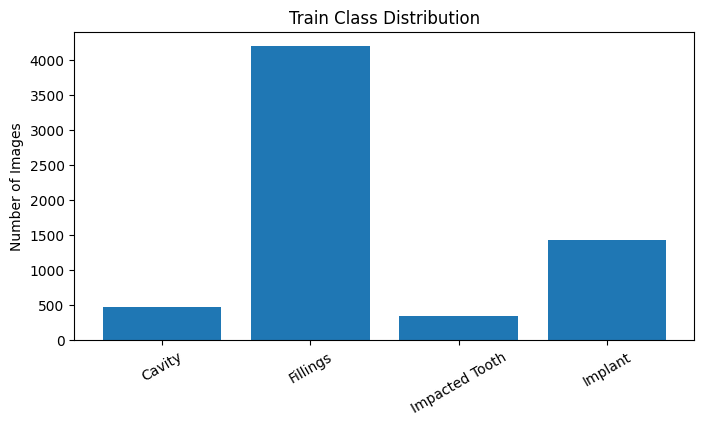

In [ ]:
import matplotlib.pyplot as plt
import os
import pandas as pd

# Calculate train_counts
train_data = []
for cls in classes:
    class_path = os.path.join(TRAIN_DIR, cls)
    num_images = len(os.listdir(class_path))
    train_data.append({"class": cls, "count": num_images})

train_counts = pd.DataFrame(train_data).set_index("class")

plt.figure(figsize=(8,4))
plt.bar(train_counts.index, train_counts["count"])
plt.title("Train Class Distribution")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.show()

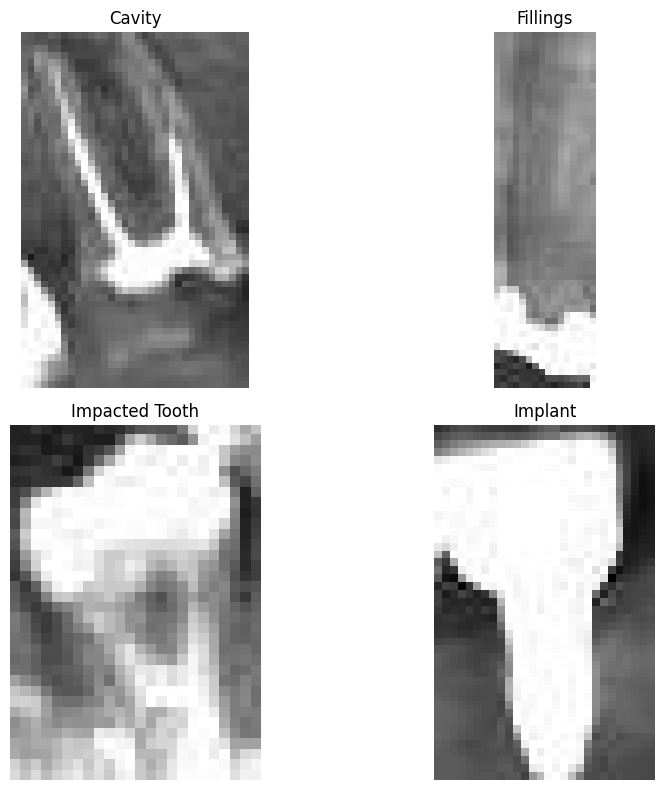

In [19]:
import random
from PIL import Image

plt.figure(figsize=(10,8))

classes = train_counts.index.tolist()

for i, cls in enumerate(classes):
    cls_dir = os.path.join("data/train", cls)
    img_name = random.choice(os.listdir(cls_dir))
    img_path = os.path.join(cls_dir, img_name)

    img = Image.open(img_path)

    plt.subplot(2, 2, i+1)
    plt.imshow(img, cmap="gray")
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

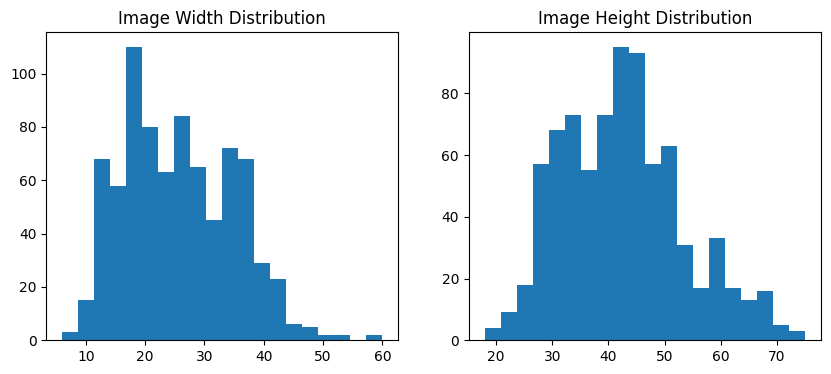

In [20]:
import numpy as np

widths, heights = [], []

for cls in classes:
    cls_dir = os.path.join("data/train", cls)
    for img_name in os.listdir(cls_dir)[:200]:  # sample for speed
        img = Image.open(os.path.join(cls_dir, img_name))
        w, h = img.size
        widths.append(w)
        heights.append(h)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(widths, bins=20)
plt.title("Image Width Distribution")

plt.subplot(1,2,2)
plt.hist(heights, bins=20)
plt.title("Image Height Distribution")

plt.show()

In [21]:
import tensorflow as tf
import cv2
import numpy as np
from PIL import Image
import os

IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def clahe_transform(image):
    def _clahe(img):
        img = img.numpy()

        if img.dtype != np.uint8:
            img = img.astype(np.uint8)

        if img.ndim == 3 and img.shape[-1] == 3:
            img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        return clahe.apply(img)

    image = tf.py_function(_clahe, [image], tf.uint8)
    image.set_shape([None, None])
    return image

    image = tf.py_function(
        _clahe,
        [image],
        Tout=tf.uint8
    )

    # shape بعد CLAHE
    image.set_shape([None, None])
    return image

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomSharpness(0.5),
])

def train_preprocess(image, label):

    image = clahe_transform(image)
    image = tf.expand_dims(image, -1)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    image = data_augmentation(image, training=True)
    image = tf.image.random_contrast(image, 0.8, 1.2)

    image = tf.cast(image, tf.float32) / 255.0
    image = (image - 0.5) / 0.5

    return image, label


def val_preprocess(image, label):

    image = clahe_transform(image)
    image = tf.expand_dims(image, -1)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    image = tf.cast(image, tf.float32) / 255.0
    image = (image - 0.5) / 0.5

    return image, label
train_ds = tf.keras.utils.image_dataset_from_directory(
    "data/train",
    label_mode="int",
    shuffle=True,
    batch_size=None   # ❗ مهم
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "data/val",
    label_mode="int",
    shuffle=False,
    batch_size=None   # ❗ مهم
)

2025-12-17 23:15:31.632422: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766013331.807330      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766013331.859119      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

I0000 00:00:1766013345.644360      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 6421 files belonging to 4 classes.
Found 1607 files belonging to 4 classes.


In [22]:
import tensorflow as tf

train_ds = (
    train_ds
    .map(train_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(val_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [23]:
import tensorflow as tf
import numpy as np
from collections import Counter

# get labels from train dataset
train_labels = []

for _, labels in train_ds.unbatch():
    train_labels.append(int(labels.numpy()))

# count samples per class
class_counts = Counter(train_labels)

# sort by class index
class_counts = dict(sorted(class_counts.items()))

print("Class counts:", class_counts)

# compute weights: total_samples / (num_classes * class_count)
num_classes = len(class_counts)
total_samples = sum(class_counts.values())

class_weights = [
    total_samples / (num_classes * class_counts[i])
    for i in range(num_classes)
]

class_weights = tf.constant(class_weights, dtype=tf.float32)

print("Class weights:", class_weights)

Class counts: {0: 460, 1: 4191, 2: 342, 3: 1428}
Class weights: tf.Tensor([3.4896739  0.38302314 4.6937137  1.1241246 ], shape=(4,), dtype=float32)


In [25]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses
from tensorflow.keras.applications import MobileNetV2

# Load MobileNetV2 with pre-trained ImageNet weights
# MobileNetV2 also expects 3-channel input
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,  # Exclude the final classification layers
    input_shape=(IMG_SIZE, IMG_SIZE, 3)  # MobileNetV2 requires 3 channels
)

# Freeze all layers in the base model
base_model.trainable = False

# Build the complete model
model = models.Sequential([
    # Convert grayscale to RGB (repeat the single channel 3 times)
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.Lambda(lambda x: tf.repeat(x, 3, axis=-1)),  # Convert 1 channel to 3
    
    # MobileNetV2 base
    base_model,
    
    # Global Average Pooling
    layers.GlobalAveragePooling2D(),
    
    # Dense layer 256 with dropout 0.5
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    
    # Dense layer 128 with dropout 0.3
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    
    # Output layer (4 classes, logits)
    layers.Dense(4)
])

# Loss function
criterion = losses.SparseCategoricalCrossentropy(from_logits=True)

# Optimizer
optimizer = optimizers.Adam(
    learning_rate=1e-4,
    weight_decay=1e-4
)

# Compile the model
model.compile(
    optimizer=optimizer,
    loss=criterion,
    metrics=['accuracy']
)

# Display model summary
model.summary()

# Verify that base_model layers are frozen
print(f"\nBase model trainable: {base_model.trainable}")
print(f"Total params: {model.count_params():,}")
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Trainable params: {trainable_params:,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,332 (9.99 MB)

 Trainable params: 361,348 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


Base model trainable: False
Total params: 2,619,332
Trainable params: 361,348


In [28]:
import tensorflow as tf

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [29]:
import tensorflow as tf
from tqdm import tqdm
import numpy as np

EPOCHS = 40

# ===== HISTORY =====
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

# ===== METRICS =====
train_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()
val_acc_metric   = tf.keras.metrics.SparseCategoricalAccuracy()

# ===== CLASS WEIGHTS =====
class_weight_tensor = tf.constant(
    [float(class_weights[i]) for i in range(len(class_weights))],
    dtype=tf.float32
)

# ===== EARLY STOPPING PARAMS =====
best_val_loss = float("inf")
early_stop_patience = 5
early_stop_counter = 0

# ===== LR SCHEDULER PARAMS (ReduceLROnPlateau) =====
lr_patience = 3
lr_counter = 0
lr_factor = 0.3
min_lr = 1e-6

# ===== TRAINING LOOP =====
for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS} [TRAIN]")
    running_loss = 0.0
    train_acc_metric.reset_state()

    # ===== TRAIN =====
    for images, labels in tqdm(train_ds):
        with tf.GradientTape() as tape:
            outputs = model(images, training=True)
            loss = criterion(labels, outputs)

            # apply class weights
            weights = tf.gather(class_weight_tensor, labels)
            loss = tf.reduce_mean(loss * weights)

        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        running_loss += loss.numpy()
        train_acc_metric.update_state(labels, outputs)

    train_loss = running_loss / tf.data.experimental.cardinality(train_ds).numpy()
    train_acc  = train_acc_metric.result().numpy()

    # ===== VALIDATION =====
    print(f"Epoch {epoch+1}/{EPOCHS} [VAL]")
    val_loss = 0.0
    val_acc_metric.reset_state()

    for images, labels in tqdm(val_ds):
        outputs = model(images, training=False)
        loss = criterion(labels, outputs)

        weights = tf.gather(class_weight_tensor, labels)
        loss = tf.reduce_mean(loss * weights)

        val_loss += loss.numpy()
        val_acc_metric.update_state(labels, outputs)

    val_loss /= tf.data.experimental.cardinality(val_ds).numpy()
    val_acc = val_acc_metric.result().numpy()

    # ===== SAVE BEST MODEL =====
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stop_counter = 0
        lr_counter = 0
        model.save_weights("best_model.weights.h5")
    else:
        early_stop_counter += 1
        lr_counter += 1

    # ===== REDUCE LR ON PLATEAU =====
    if lr_counter >= lr_patience:
        old_lr = optimizer.learning_rate.numpy()
        new_lr = max(old_lr * lr_factor, min_lr)
        optimizer.learning_rate.assign(new_lr)
        lr_counter = 0
        print(f"LR reduced: {old_lr:.2e} → {new_lr:.2e}")

    # ===== EARLY STOPPING =====
    if early_stop_counter >= early_stop_patience:
        print("Early stopping triggered")
        break

    # ===== HISTORY =====
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    # ===== PRINT =====
    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )


Epoch 1/40 [TRAIN]


100%|██████████| 201/201 [01:37<00:00,  2.06it/s]


Epoch 1/40 [VAL]


100%|██████████| 51/51 [00:10<00:00,  5.08it/s]


Epoch [1/40] | Train Loss: 1.1157 | Train Acc: 0.5920 | Val Loss: 1.3288 | Val Acc: 0.7281

Epoch 2/40 [TRAIN]


100%|██████████| 201/201 [02:21<00:00,  1.42it/s]


Epoch 2/40 [VAL]


100%|██████████| 51/51 [00:10<00:00,  5.07it/s]


Epoch [2/40] | Train Loss: 0.7910 | Train Acc: 0.7083 | Val Loss: 1.0234 | Val Acc: 0.7959

Epoch 3/40 [TRAIN]


100%|██████████| 201/201 [01:35<00:00,  2.10it/s]


Epoch 3/40 [VAL]


100%|██████████| 51/51 [00:10<00:00,  5.09it/s]


Epoch [3/40] | Train Loss: 0.6794 | Train Acc: 0.7489 | Val Loss: 0.8926 | Val Acc: 0.8127

Epoch 4/40 [TRAIN]


100%|██████████| 201/201 [01:35<00:00,  2.10it/s]


Epoch 4/40 [VAL]


100%|██████████| 51/51 [00:10<00:00,  5.07it/s]


Epoch [4/40] | Train Loss: 0.5972 | Train Acc: 0.7852 | Val Loss: 0.8193 | Val Acc: 0.8382

Epoch 5/40 [TRAIN]


100%|██████████| 201/201 [01:35<00:00,  2.11it/s]


Epoch 5/40 [VAL]


100%|██████████| 51/51 [00:10<00:00,  4.91it/s]


Epoch [5/40] | Train Loss: 0.5505 | Train Acc: 0.8078 | Val Loss: 0.8071 | Val Acc: 0.8376

Epoch 6/40 [TRAIN]


100%|██████████| 201/201 [01:35<00:00,  2.11it/s]


Epoch 6/40 [VAL]


100%|██████████| 51/51 [00:10<00:00,  5.08it/s]


Epoch [6/40] | Train Loss: 0.5217 | Train Acc: 0.8134 | Val Loss: 0.7334 | Val Acc: 0.8475

Epoch 7/40 [TRAIN]


100%|██████████| 201/201 [01:35<00:00,  2.10it/s]


Epoch 7/40 [VAL]


100%|██████████| 51/51 [00:10<00:00,  5.01it/s]


Epoch [7/40] | Train Loss: 0.5002 | Train Acc: 0.8292 | Val Loss: 0.7049 | Val Acc: 0.8556

Epoch 8/40 [TRAIN]


100%|██████████| 201/201 [01:35<00:00,  2.11it/s]


Epoch 8/40 [VAL]


100%|██████████| 51/51 [00:10<00:00,  5.05it/s]


Epoch [8/40] | Train Loss: 0.4693 | Train Acc: 0.8332 | Val Loss: 0.6991 | Val Acc: 0.8463

Epoch 9/40 [TRAIN]


100%|██████████| 201/201 [02:21<00:00,  1.42it/s]


Epoch 9/40 [VAL]


100%|██████████| 51/51 [00:10<00:00,  5.03it/s]


Epoch [9/40] | Train Loss: 0.4415 | Train Acc: 0.8485 | Val Loss: 0.6613 | Val Acc: 0.8475

Epoch 10/40 [TRAIN]


100%|██████████| 201/201 [01:35<00:00,  2.11it/s]


Epoch 10/40 [VAL]


100%|██████████| 51/51 [00:09<00:00,  5.12it/s]


Epoch [10/40] | Train Loss: 0.4229 | Train Acc: 0.8488 | Val Loss: 0.6599 | Val Acc: 0.8513

Epoch 11/40 [TRAIN]


100%|██████████| 201/201 [02:21<00:00,  1.42it/s]


Epoch 11/40 [VAL]


100%|██████████| 51/51 [00:10<00:00,  5.04it/s]


Epoch [11/40] | Train Loss: 0.4203 | Train Acc: 0.8524 | Val Loss: 0.6134 | Val Acc: 0.8550

Epoch 12/40 [TRAIN]


100%|██████████| 201/201 [01:35<00:00,  2.12it/s]


Epoch 12/40 [VAL]


100%|██████████| 51/51 [00:10<00:00,  5.08it/s]


Epoch [12/40] | Train Loss: 0.4171 | Train Acc: 0.8566 | Val Loss: 0.6143 | Val Acc: 0.8681

Epoch 13/40 [TRAIN]


100%|██████████| 201/201 [01:34<00:00,  2.12it/s]


Epoch 13/40 [VAL]


100%|██████████| 51/51 [00:10<00:00,  5.06it/s]


Epoch [13/40] | Train Loss: 0.3838 | Train Acc: 0.8672 | Val Loss: 0.6019 | Val Acc: 0.8643

Epoch 14/40 [TRAIN]


100%|██████████| 201/201 [01:35<00:00,  2.11it/s]


Epoch 14/40 [VAL]


100%|██████████| 51/51 [00:10<00:00,  5.01it/s]


Epoch [14/40] | Train Loss: 0.3765 | Train Acc: 0.8684 | Val Loss: 0.6299 | Val Acc: 0.8687

Epoch 15/40 [TRAIN]


100%|██████████| 201/201 [01:34<00:00,  2.12it/s]


Epoch 15/40 [VAL]


100%|██████████| 51/51 [00:10<00:00,  5.07it/s]


Epoch [15/40] | Train Loss: 0.3814 | Train Acc: 0.8721 | Val Loss: 0.5964 | Val Acc: 0.8581

Epoch 16/40 [TRAIN]


100%|██████████| 201/201 [01:35<00:00,  2.11it/s]


Epoch 16/40 [VAL]


100%|██████████| 51/51 [00:10<00:00,  5.01it/s]


Epoch [16/40] | Train Loss: 0.3680 | Train Acc: 0.8740 | Val Loss: 0.6153 | Val Acc: 0.8662

Epoch 17/40 [TRAIN]


100%|██████████| 201/201 [01:35<00:00,  2.10it/s]


Epoch 17/40 [VAL]


100%|██████████| 51/51 [00:10<00:00,  5.09it/s]


Epoch [17/40] | Train Loss: 0.3582 | Train Acc: 0.8765 | Val Loss: 0.6345 | Val Acc: 0.8836

Epoch 18/40 [TRAIN]


100%|██████████| 201/201 [01:35<00:00,  2.11it/s]


Epoch 18/40 [VAL]


100%|██████████| 51/51 [00:10<00:00,  5.05it/s]


Epoch [18/40] | Train Loss: 0.3493 | Train Acc: 0.8852 | Val Loss: 0.5754 | Val Acc: 0.8755

Epoch 19/40 [TRAIN]


100%|██████████| 201/201 [01:35<00:00,  2.10it/s]


Epoch 19/40 [VAL]


100%|██████████| 51/51 [00:10<00:00,  5.05it/s]


Epoch [19/40] | Train Loss: 0.3353 | Train Acc: 0.8846 | Val Loss: 0.5715 | Val Acc: 0.8780

Epoch 20/40 [TRAIN]


100%|██████████| 201/201 [01:35<00:00,  2.11it/s]


Epoch 20/40 [VAL]


100%|██████████| 51/51 [00:09<00:00,  5.11it/s]


Epoch [20/40] | Train Loss: 0.3404 | Train Acc: 0.8807 | Val Loss: 0.6402 | Val Acc: 0.8681

Epoch 21/40 [TRAIN]


100%|██████████| 201/201 [01:35<00:00,  2.11it/s]


Epoch 21/40 [VAL]


100%|██████████| 51/51 [00:09<00:00,  5.13it/s]


Epoch [21/40] | Train Loss: 0.3329 | Train Acc: 0.8860 | Val Loss: 0.6494 | Val Acc: 0.8755

Epoch 22/40 [TRAIN]


100%|██████████| 201/201 [01:33<00:00,  2.14it/s]


Epoch 22/40 [VAL]


100%|██████████| 51/51 [00:09<00:00,  5.17it/s]


LR reduced: 1.00e-04 → 3.00e-05
Epoch [22/40] | Train Loss: 0.3224 | Train Acc: 0.8896 | Val Loss: 0.6527 | Val Acc: 0.8693

Epoch 23/40 [TRAIN]


100%|██████████| 201/201 [01:34<00:00,  2.13it/s]


Epoch 23/40 [VAL]


100%|██████████| 51/51 [00:10<00:00,  5.10it/s]


Epoch [23/40] | Train Loss: 0.3107 | Train Acc: 0.8963 | Val Loss: 0.6201 | Val Acc: 0.8693

Epoch 24/40 [TRAIN]


100%|██████████| 201/201 [01:34<00:00,  2.12it/s]


Epoch 24/40 [VAL]


100%|██████████| 51/51 [00:10<00:00,  5.09it/s]

Early stopping triggered


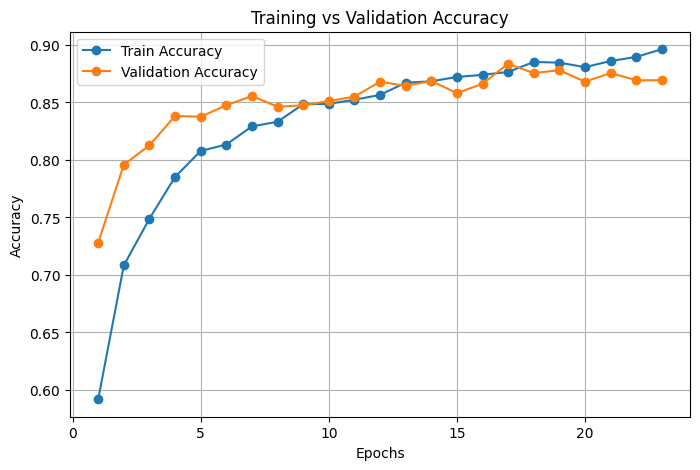

In [34]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_acc"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, history["train_acc"], label="Train Accuracy", marker="o")
plt.plot(epochs, history["val_acc"], label="Validation Accuracy", marker="o")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

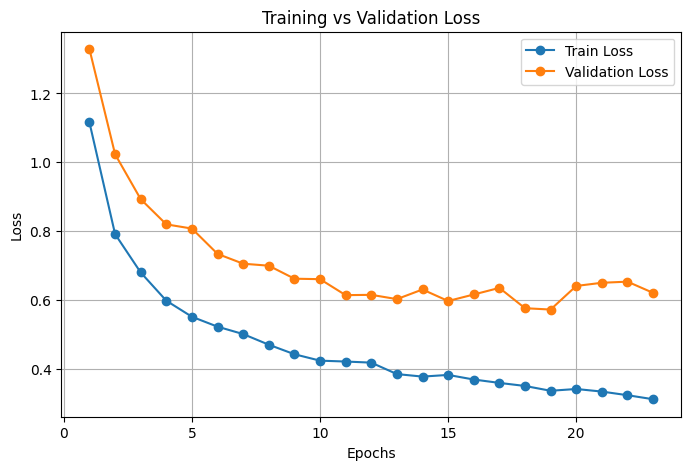

In [35]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, history["train_loss"], label="Train Loss", marker="o")
plt.plot(epochs, history["val_loss"], label="Validation Loss", marker="o")
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [36]:
raw_val_ds = tf.keras.utils.image_dataset_from_directory(
    "data/val",
    label_mode="int",
    shuffle=False,
    batch_size=None
)

class_names = raw_val_ds.class_names

val_ds = (
    raw_val_ds
    .map(val_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

Found 1607 files belonging to 4 classes.


In [38]:
import tensorflow as tf
import numpy as np

y_pred = []
y_true = []

for images, labels in val_ds:
    outputs = model(images, training=False)
    preds = tf.argmax(outputs, axis=1)

    y_pred.extend(preds.numpy())
    y_true.extend(labels.numpy())

y_pred = np.array(y_pred)
y_true = np.array(y_true)



In [39]:
import numpy as np
import random

errors = np.where(y_pred != y_true)[0]
print("Total errors:", len(errors))

sample_errors = random.sample(list(errors), min(9, len(errors)))


Total errors: 211


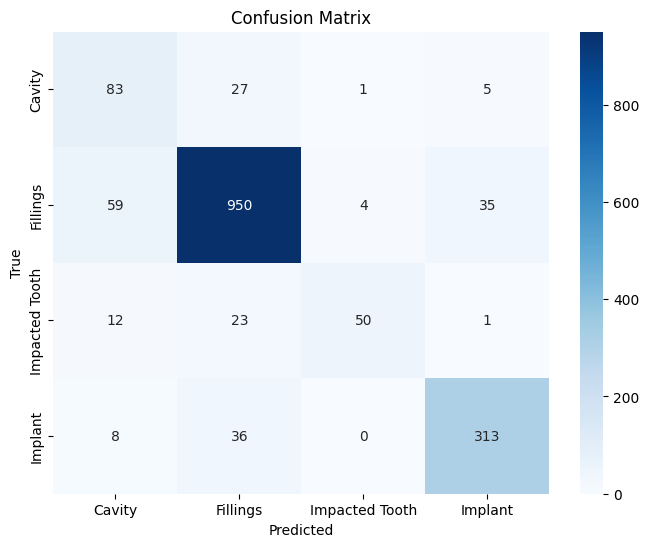

In [41]:

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [42]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

                precision    recall  f1-score   support

        Cavity     0.5123    0.7155    0.5971       116
      Fillings     0.9170    0.9065    0.9117      1048
Impacted Tooth     0.9091    0.5814    0.7092        86
       Implant     0.8842    0.8768    0.8805       357

      accuracy                         0.8687      1607
     macro avg     0.8057    0.7700    0.7746      1607
  weighted avg     0.8801    0.8687    0.8712      1607



In [43]:
accuracy = (y_pred == y_true).mean() * 100
print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 86.87%


In [44]:
import tensorflow as tf

model.save_weights("cnn_model.weights.h5")
print("Model saved successfully!")

Model saved successfully!


In [45]:
import json

history_clean = {
    k: [float(v) for v in values]
    for k, values in history.items()
}

with open("cnn_history.json", "w") as f:
    json.dump(history_clean, f, indent=4)

print("History saved successfully!")

History saved successfully!
